## Examples

[This Jupyter Notebook]() aims at showing the properties of the `expandLHS` module.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats.qmc import LatinHypercube
# the following import ensure to load the latest version of the module
# the user should install the module and then import it as usual
from importlib.machinery import SourceFileLoader
expandLHS = SourceFileLoader("expandLHS", "../expandLHS/expandLHS.py").load_module()
from expandLHS import ExpandLHS
import plotter

### Sample a Latin Hypercube

Let's start sampling a random Latin Hypercube as implemented in Scipy.stats.qmc.LatinHypercube.

(<Figure size 600x600 with 1 Axes>, <Axes: xlabel='P1', ylabel='P2'>)

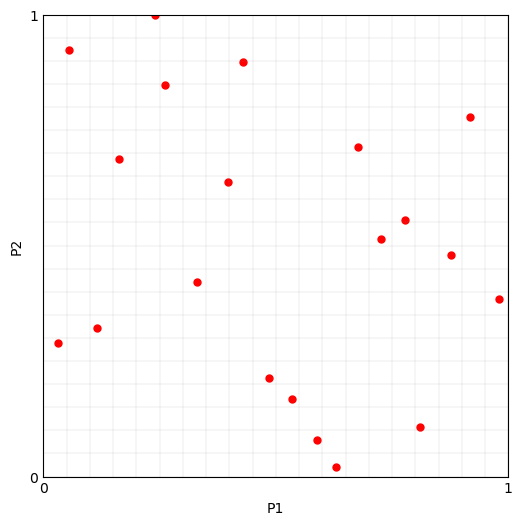

In [2]:
N = 20 # number of samples
P = 2 # number of dimensions

lhs_sampler = LatinHypercube(P)
lhs_set = lhs_sampler.random(N)

plotter.plot(lhs_set, M=0, x_label='P1', y_label='P2')

### Expand the Latin Hypercube

Now the aim is to add new samples without modifying the ones we already sampled. \
This procedure may cause two samples to fall in the same interval, even if they do not overlap in the initial set. \
As a first step we need to resize our gridding with `ExpandLHS.regridding`. \
The method `ExpandLHS.count_samples` comput the number of samples in each interval for each dimension. 

(<Figure size 600x600 with 1 Axes>, <Axes: xlabel='P1', ylabel='P2'>)

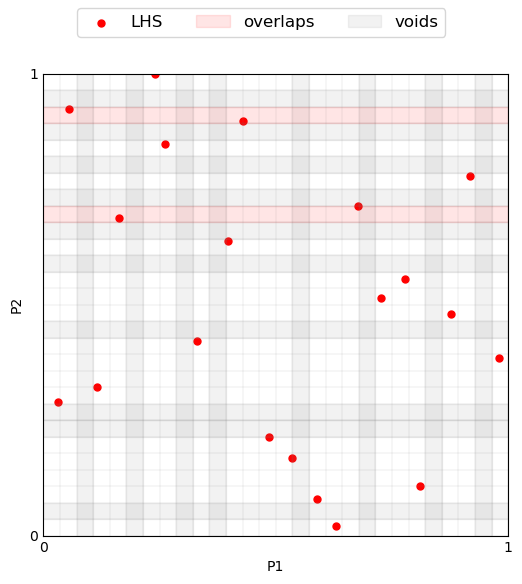

In [ ]:
M = 5 # number of samples to add

eLHS = ExpandLHS(lhs_set)
voids = eLHS.regridding(M)
overlaps = eLHS.count_samples(M)

#the plot function internally compute both voids and overlaps
plotter.plot(lhs_set, M=M, labels='LHS', voids=voids, overlaps=overlaps, x_label='P1', y_label='P2') 

Then, is it possible to perform the expansion by `ExpandLHS.__call__`

(<Figure size 600x600 with 1 Axes>, <Axes: >)

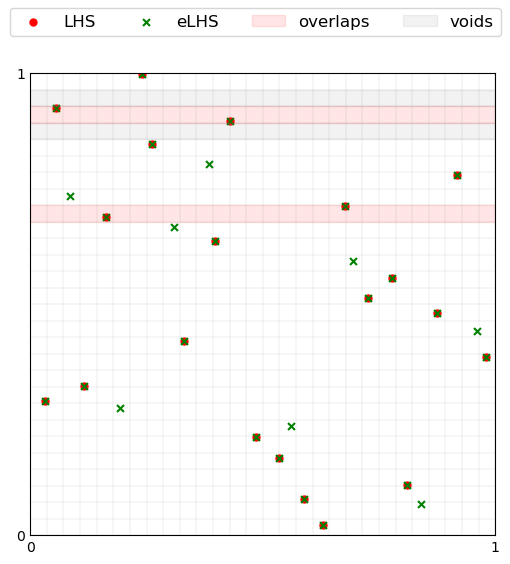

In [4]:
lhs_set_expanded = eLHS(M)
voids = eLHS.regridding(0, samples=lhs_set_expanded) #recompute voids on the expanded set

plotter.plot([lhs_set, lhs_set_expanded], M=0, labels=['LHS', 'eLHS'], \
    colors=['red', 'green'], markers=['o', 'x'], sizes=[25, 25], \
    index = 1, voids=voids, overlaps=overlaps)

### Degree of an expansion

The regridding of the space may cause some overlaps and voids, which imply that the new set is not a Latin Hypercube anymore.
We define a quantity to measure the degree-of-LHS of a samples set. \
This estimate is performed with the method `ExpandLHS.degree`. \
A perfect Latin Hypercube has always a degree of 1. 

In [5]:
degree = eLHS.degree(M)
print(f'degree-of-LHS = {degree:.3f}')

degree-of-LHS = 0.964


Using the method `ExpandLHS.optimal_expansion` it is possible to compute the degree-of-LHS for different expansion sizes in a given interval. 

In [6]:
expansions = eLHS.optimal_expansion((4, 9), verbose=True)
print(f'List of expansions sorted by the corresponding degree:')
for expansion in expansions:
    print(expansion)

List of expansions sorted by the corresponding degree:
(0, 1.0)
(9, 0.9827586206896551)
(8, 0.9642857142857143)
(7, 0.962962962962963)
(6, 0.9423076923076923)
(5, 0.94)
(1, 0.8809523809523809)


### Optimized expansion

Scipy's implementation of Latin Hypercube sampling allows to optimize the sample set using the discrepancy (Scipy.stats.qmc.discrepancy) as a metric. \
A lower discrepancy corresponds to a better space-filling.

In [ ]:
from scipy.stats.qmc import discrepancy

N = 100
P = 6
M = 92

lhs_sampler = LatinHypercube(P)
lhs_set = lhs_sampler.random(N)
lhs_sampler_opt = LatinHypercube(P, optimization='random-cd')
lhs_set_opt = lhs_sampler_opt.random(N)

print(f'Discrepancy of LHS without optimization: {discrepancy(lhs_set):.4f}')
print(f'Discrepancy of LHS with optimization: {discrepancy(lhs_set_opt):.4f}')


Discrepancy of LHS without optimization: 0.0075
Discrepancy of LHS with optimization: 0.0025


When using `ExpandLHS.__call__` is it possible to ask for an optimized expansion with the keyword `optimize=`, where the available metrics are: 
- discrepancy (Scipy.stats.qmc.discrepancy)
- geometric discrepancy (Scipy.stats.qmc.geometric_discrepancy)

In [9]:
lhs_set_expanded_opt = eLHS(M, optimize='discrepancy')

print(f'Discrepancy of eLHS without optimization: {discrepancy(lhs_set_expanded):.4f}')
print(f'Discrepancy of eLHS with optimization: {discrepancy(lhs_set_expanded_opt):.4f}')

Discrepancy of eLHS without optimization: 0.0023
Discrepancy of eLHS with optimization: 0.0002
